# Proyecto ETL: Análisis de Evasión de Clientes (Churn) - Telecom X

Objetivo: Identificar los factores que impulsan la pérdida de clientes mediante un proceso de limpieza, transformación y análisis exploratorio de datos (EDA).

## 1. Extracción
Cargamos los datos directamente desde la fuente y realizamos una inspección inicial.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configuración estética
sns.set_theme(style="whitegrid")
pd.options.display.max_columns = None

# URL de los datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Lectura y normalización inicial (Aplanamos la estructura anidada)
df_raw = pd.read_json(url)
df = pd.json_normalize(df_raw.to_dict(orient="records"))

print(f"Dimensiones iniciales: {df.shape}")
df.head()

Dimensiones iniciales: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 2. Transformación
En esta etapa limpiamos inconsistencias, traducimos variables y preparamos los datos para el análisis.

### 2.1 Auditoria de datos trampa

In [7]:
# Trampa A: Espacios vacíos en texto en lugar de valores nulos reales
espacios_totales = (df['account.Charges.Total'] == " ").sum()
print(f"- Espacios en blanco detectados en Cargos Totales: {espacios_totales}")

# Trampa B: Inconsistencia en clientes nuevos
# Verificamos si hay clientes con 0 meses pero que ya tienen cargos (lo cual sería un error de sistema)
inconsistentes = df[(df['customer.tenure'] == 0) & (df['account.Charges.Total'] != " ")].shape[0]
print(f"- Clientes nuevos con cargos totales incoherentes: {inconsistentes}")

# Trampa C: Registros sin etiquetas (Churn vacío)
sin_etiqueta = (df['Churn'] == "").sum()
print(f"- Registros sin información de Evasión (Churn): {sin_etiqueta}")

- Espacios en blanco detectados en Cargos Totales: 0
- Clientes nuevos con cargos totales incoherentes: 11
- Registros sin información de Evasión (Churn): 0


Obtuvimos 11 cargos incoherentes, pero asumires que estos se deben a cargos de instalacion que son comunes en el servicio.

### Limpieza y estandarizacion.

In [8]:
# 1. Limpieza de valores críticos
# Eliminamos filas donde Churn está vacío o no es Yes/No
df = df[df['Churn'].isin(['Yes', 'No'])].copy()

# 2. Corrección de tipos de datos
# Convertimos cargos totales a numérico (manejando espacios en blanco como NaN)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce').fillna(0)

# 3. Ingeniería de Variables (Feature Engineering)
# Creamos la métrica de gasto diario
df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)

# 4. Traducción y Estandarización
columnas_finales = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.tenure': 'Meses_Contrato',
    'internet.InternetService': 'Servicio_Internet',
    'account.Contract': 'Tipo_Contrato',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargos_Mensuales',
    'account.Charges.Total': 'Cargos_Totales'
}

# Renombramos y seleccionamos solo las columnas esenciales para este análisis
df_clean = df.rename(columns=columnas_finales)[columnas_finales.values()].copy()
df_clean['Evasion_Binaria'] = df_clean['Evasion'].map({'Yes': 1, 'No': 0})

print("Transformación completada. Datos listos para análisis.")
df_clean.info()

Transformación completada. Datos listos para análisis.
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7266
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_Cliente         7043 non-null   object 
 1   Evasion            7043 non-null   object 
 2   Genero             7043 non-null   object 
 3   Adulto_Mayor       7043 non-null   int64  
 4   Meses_Contrato     7043 non-null   int64  
 5   Servicio_Internet  7043 non-null   object 
 6   Tipo_Contrato      7043 non-null   object 
 7   Metodo_Pago        7043 non-null   object 
 8   Cargos_Mensuales   7043 non-null   float64
 9   Cargos_Totales     7043 non-null   float64
 10  Evasion_Binaria    7043 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 660.3+ KB


## 3. Carga y Análisis Exploratorio (EDA)
Visualizamos la distribución de la evasión y los perfiles de los clientes.

### 3.1 Distribución General de Evasión

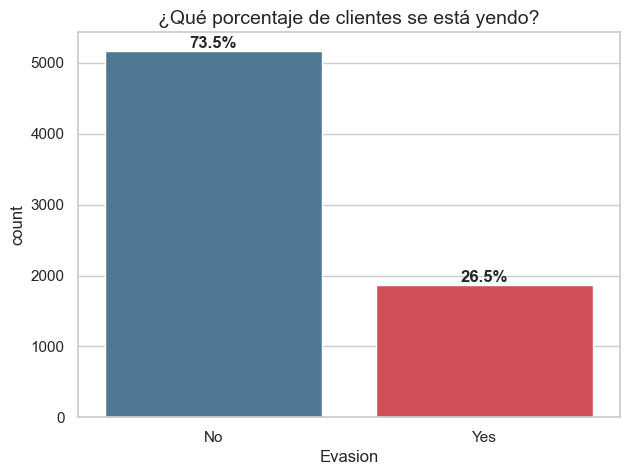

In [4]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_clean, x='Evasion', palette={'Yes': '#E63946', 'No': '#457B9D'})
total = len(df_clean)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('¿Qué porcentaje de clientes se está yendo?', fontsize=14)
plt.show()

### 3.2 Impacto del Contrato y el Gasto
Analizamos cómo el tipo de contrato influye en la permanencia.

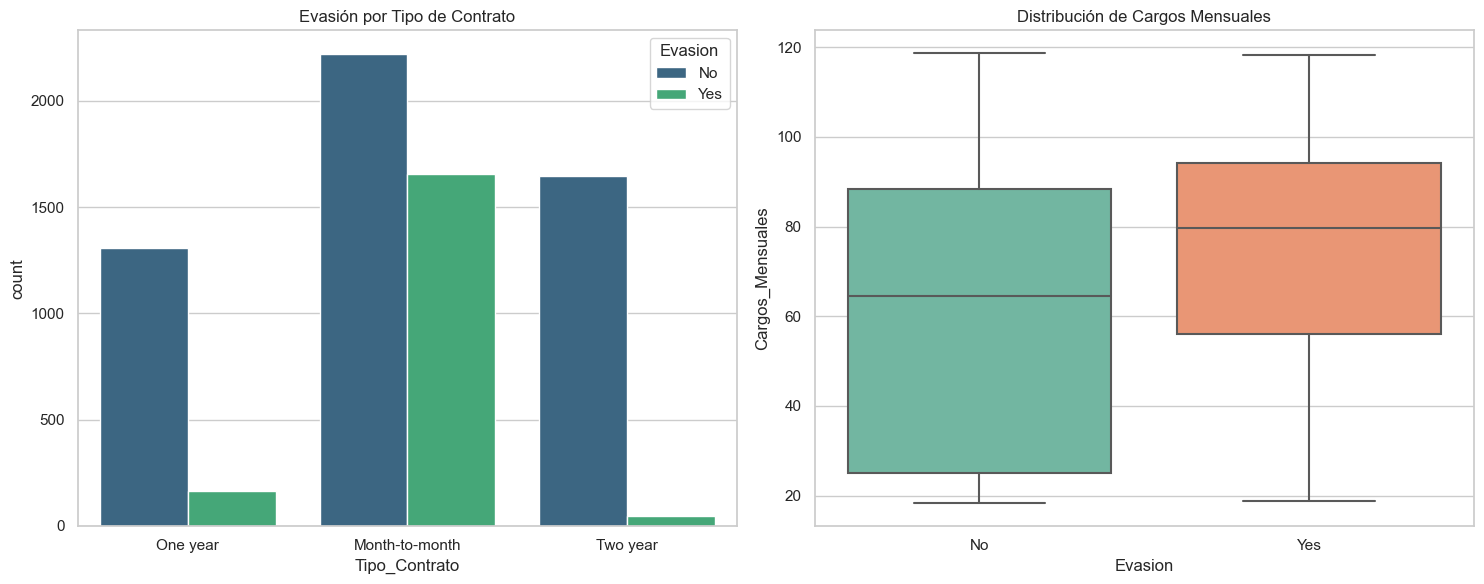

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualización 1: Tipo de Contrato
sns.countplot(data=df_clean, x='Tipo_Contrato', hue='Evasion', palette='viridis', ax=axes[0])
axes[0].set_title('Evasión por Tipo de Contrato')

# Visualización 2: Cargos Mensuales vs Evasión
sns.boxplot(data=df_clean, x='Evasion', y='Cargos_Mensuales', palette='Set2', ax=axes[1])
axes[1].set_title('Distribución de Cargos Mensuales')

plt.tight_layout()
plt.show()

## 4. Análisis de Correlación
Identificamos numéricamente qué variables están más ligadas al abandono.

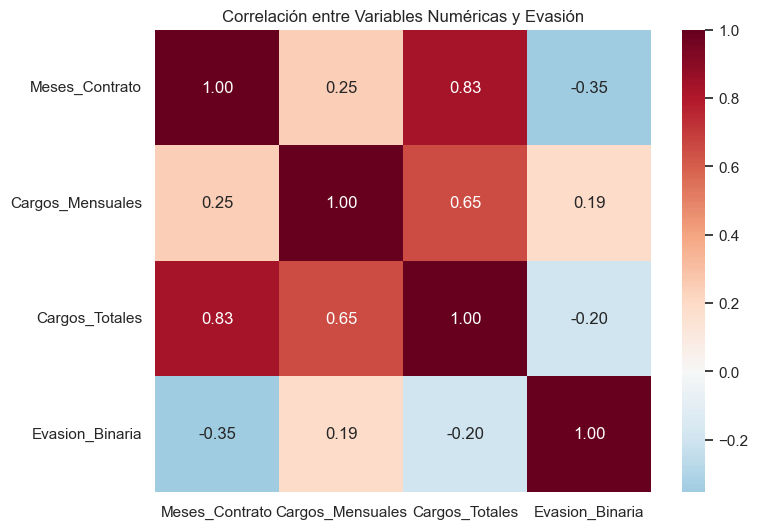

In [6]:
# Seleccionamos variables numéricas para la matriz
cols_para_corr = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Evasion_Binaria']
matriz_corr = df_clean[cols_para_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlación entre Variables Numéricas y Evasión')
plt.show()

In [10]:
df_clean.to_csv('df_clean.csv', index=False)

## 5. Informe Final

**Hallazgos Críticos (Insights):**

- El Factor Tiempo: Existe una correlación negativa moderada (-0.35) entre la antigüedad (Meses_Contrato) y la evasión. Los clientes nuevos son los más propensos a irse.

- Contratos de Corto Plazo: Los contratos "Mes a mes" tienen la tasa de fuga más alta. La estabilidad aumenta drásticamente con contratos de 1 o 2 años.

- Costo del Servicio: Los clientes que abandonan suelen tener cargos mensuales más altos en comparación con los que se quedan.

**Recomendaciones Estratégicas**

- Incentivos de Permanencia: Crear promociones para migrar a clientes de contratos mensuales a contratos anuales.

- Plan de Bienvenida: Implementar un programa de "Atención Prioritaria" durante los primeros 6 meses del cliente para asegurar su fidelización inicial.

- Revisión de Tarifas: Analizar si los clientes con cargos superiores a $70/mes están recibiendo suficiente valor percibido o si requieren descuentos por lealtad.